In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../Coffee Shop Sales.xlsx',sheet_name='Transactions')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


# Data Cleaning

In [4]:
# set transaction_id as dataframe index
df.set_index('transaction_id')

# removed the transaction_id column and overwrited the df
df.drop('transaction_id', inplace=True,axis='columns')

In [5]:
df.columns

Index(['transaction_date', 'transaction_time', 'transaction_qty', 'store_id',
       'store_location', 'product_id', 'unit_price', 'product_category',
       'product_type', 'product_detail'],
      dtype='object')

In [6]:
# df.drop(['Revenue', 'Month', 'Month.1', 'Weekday', 'Weekday.1', ], inplace=True, axis='columns')a

In [7]:
# checking the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_date  149116 non-null  datetime64[ns]
 1   transaction_time  149116 non-null  object        
 2   transaction_qty   149116 non-null  int64         
 3   store_id          149116 non-null  int64         
 4   store_location    149116 non-null  object        
 5   product_id        149116 non-null  int64         
 6   unit_price        149116 non-null  float64       
 7   product_category  149116 non-null  object        
 8   product_type      149116 non-null  object        
 9   product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 11.4+ MB


In [8]:
# changing the time of transaction_time
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

In [9]:
# Remove leading/trailing whitespace from strings
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
# check for null values
df.isna().sum()

transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [10]:
# check for duplicate values
df.duplicated().sum()

# drop duplicates
df.drop_duplicates(inplace=True)

# Exploratory analysis

In [12]:
# Revenue
df['revenue'] = df['transaction_qty'] * df['unit_price']

In [13]:
df[['transaction_qty', 'unit_price', 'revenue']].describe()

,transaction_qty,unit_price,revenue
count,148718.000000,148718.000000,148718.000000
mean,1.439402,3.381732,4.689239
std,0.542754,2.662131,4.232286
min,1.000000,0.800000,0.800000
25%,1.000000,2.500000,3.000000
50%,1.000000,3.000000,3.750000
75%,2.000000,3.750000,6.000000
max,8.000000,45.000000,360.000000


In [14]:
df.head()

,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [15]:
corr_df = df[['transaction_qty', 'store_id', 'unit_price', 'product_id', 'revenue']]
# calculate the correlation matrix
corr = corr_df.corr()

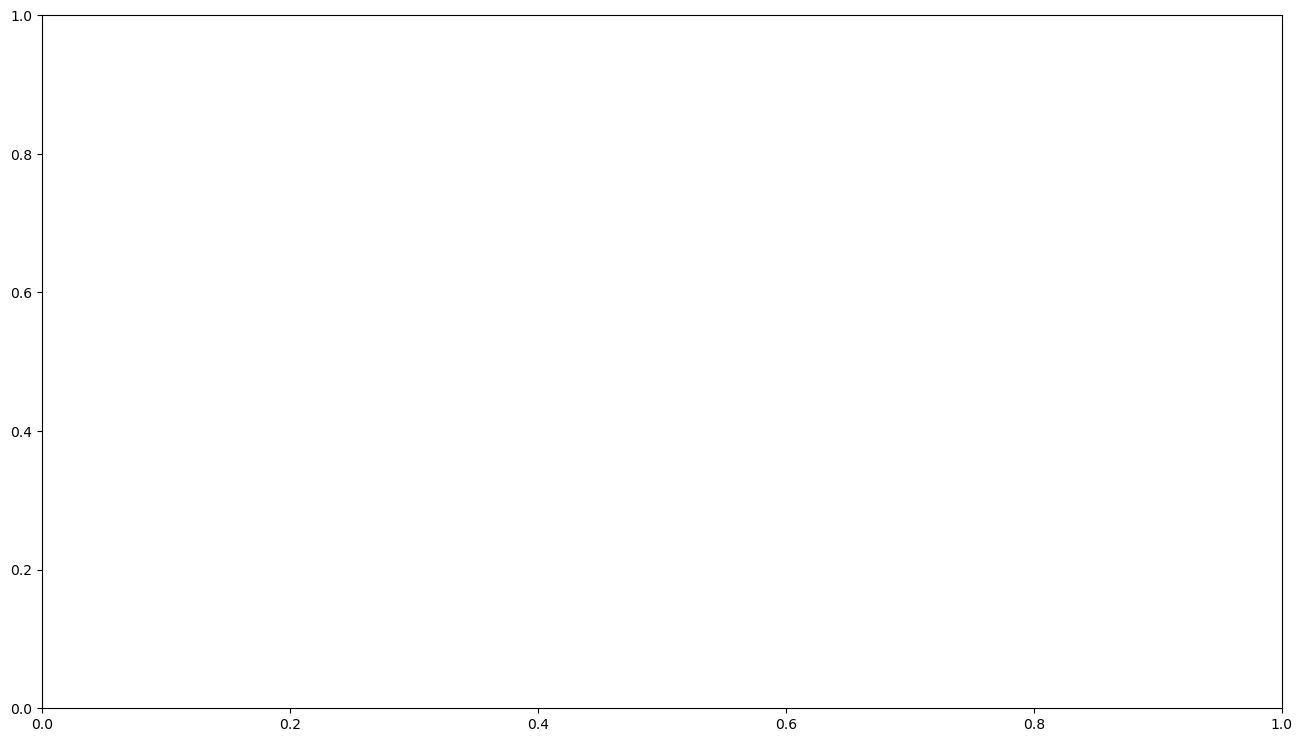

In [16]:
# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(16,9))

# Generate a mask for the upper triangle and store it in the mask variable
mask = np.triu(np.ones_like(corr, dtype=bool))

<Axes: >

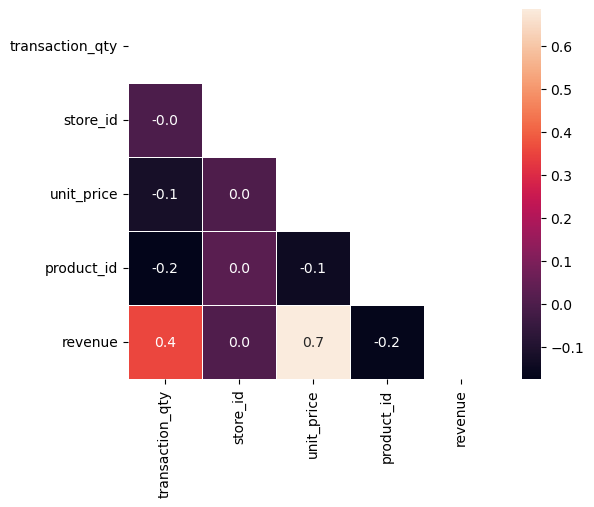

In [67]:
import seaborn as sns
# Plot the correlation matrix using the method provided by the seaborn library import: sns.heatmap()
sns.heatmap(corr, mask=mask, square=True, linewidths=0.5, annot=True, fmt='0.1f')

## Revenue & Transactions count by product

In [19]:
# Revenue by product
rev_by_prod = df.groupby(by=['product_type'])['revenue'].sum().sort_values(ascending=False)

# count of each product
tc_by_prod = df['product_type'].value_counts().sort_values(ascending=False)

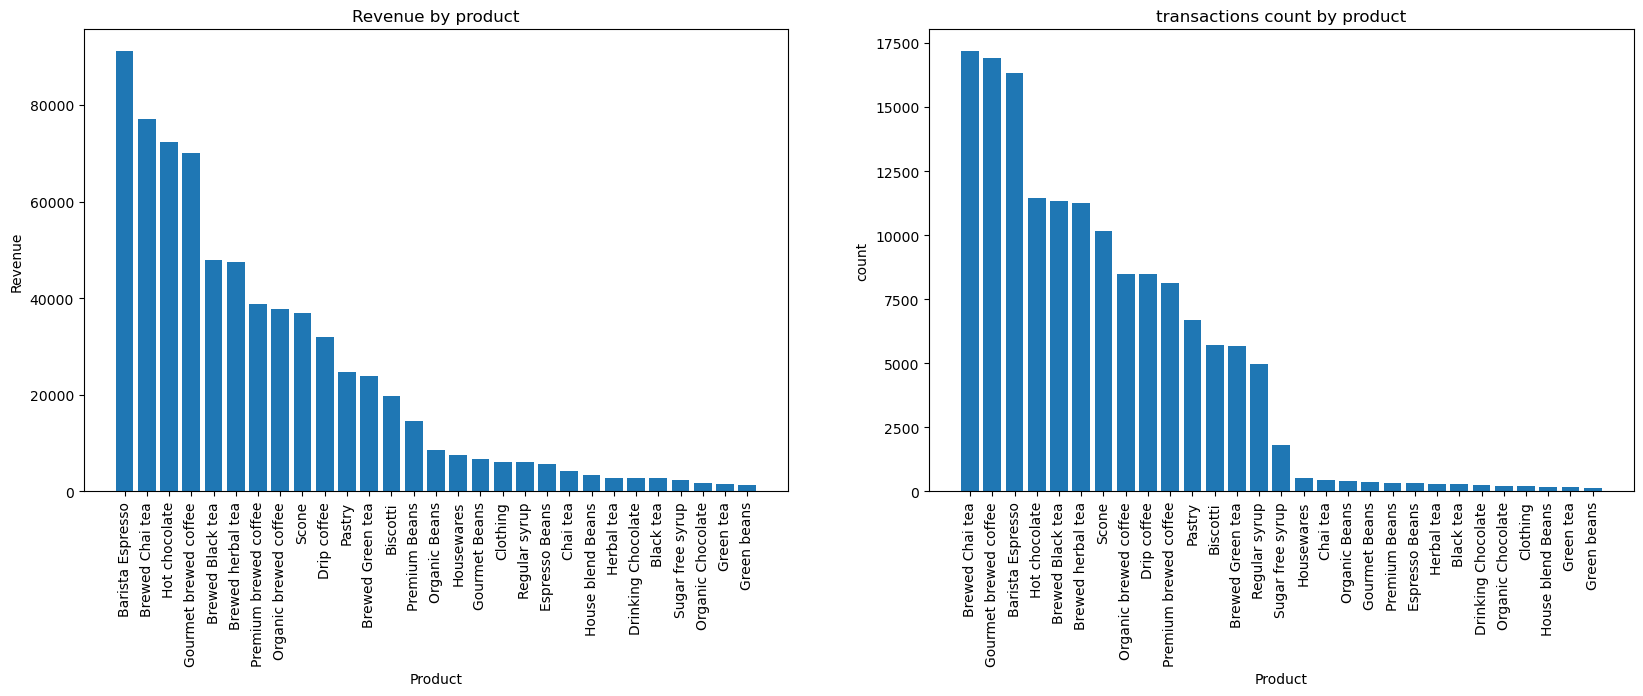

In [20]:
# bar chart
fig, axs = plt.subplots(1, 2, figsize=(20,6))

# first graph || sales
axs[0].bar(rev_by_prod.index, rev_by_prod)
axs[0].set_title('Revenue by product')
axs[0].set_xlabel('Product')
axs[0].set_ylabel('Revenue')
axs[0].tick_params(axis='x', rotation=90)


# second graph || sales
axs[1].bar(tc_by_prod.index, tc_by_prod)
axs[1].set_xlabel('Product')
axs[1].set_ylabel('count')
axs[1].tick_params(axis='x', rotation=90)
axs[1].set_title('transactions count by product')

plt.show()

## Revenue & Transactions count by Category

In [22]:
# Revenue by Category
rev_by_cat = df.groupby(by=['product_category'])['revenue'].sum().sort_values()

# count of each Category
tc_by_cat = df['product_category'].value_counts().sort_values()

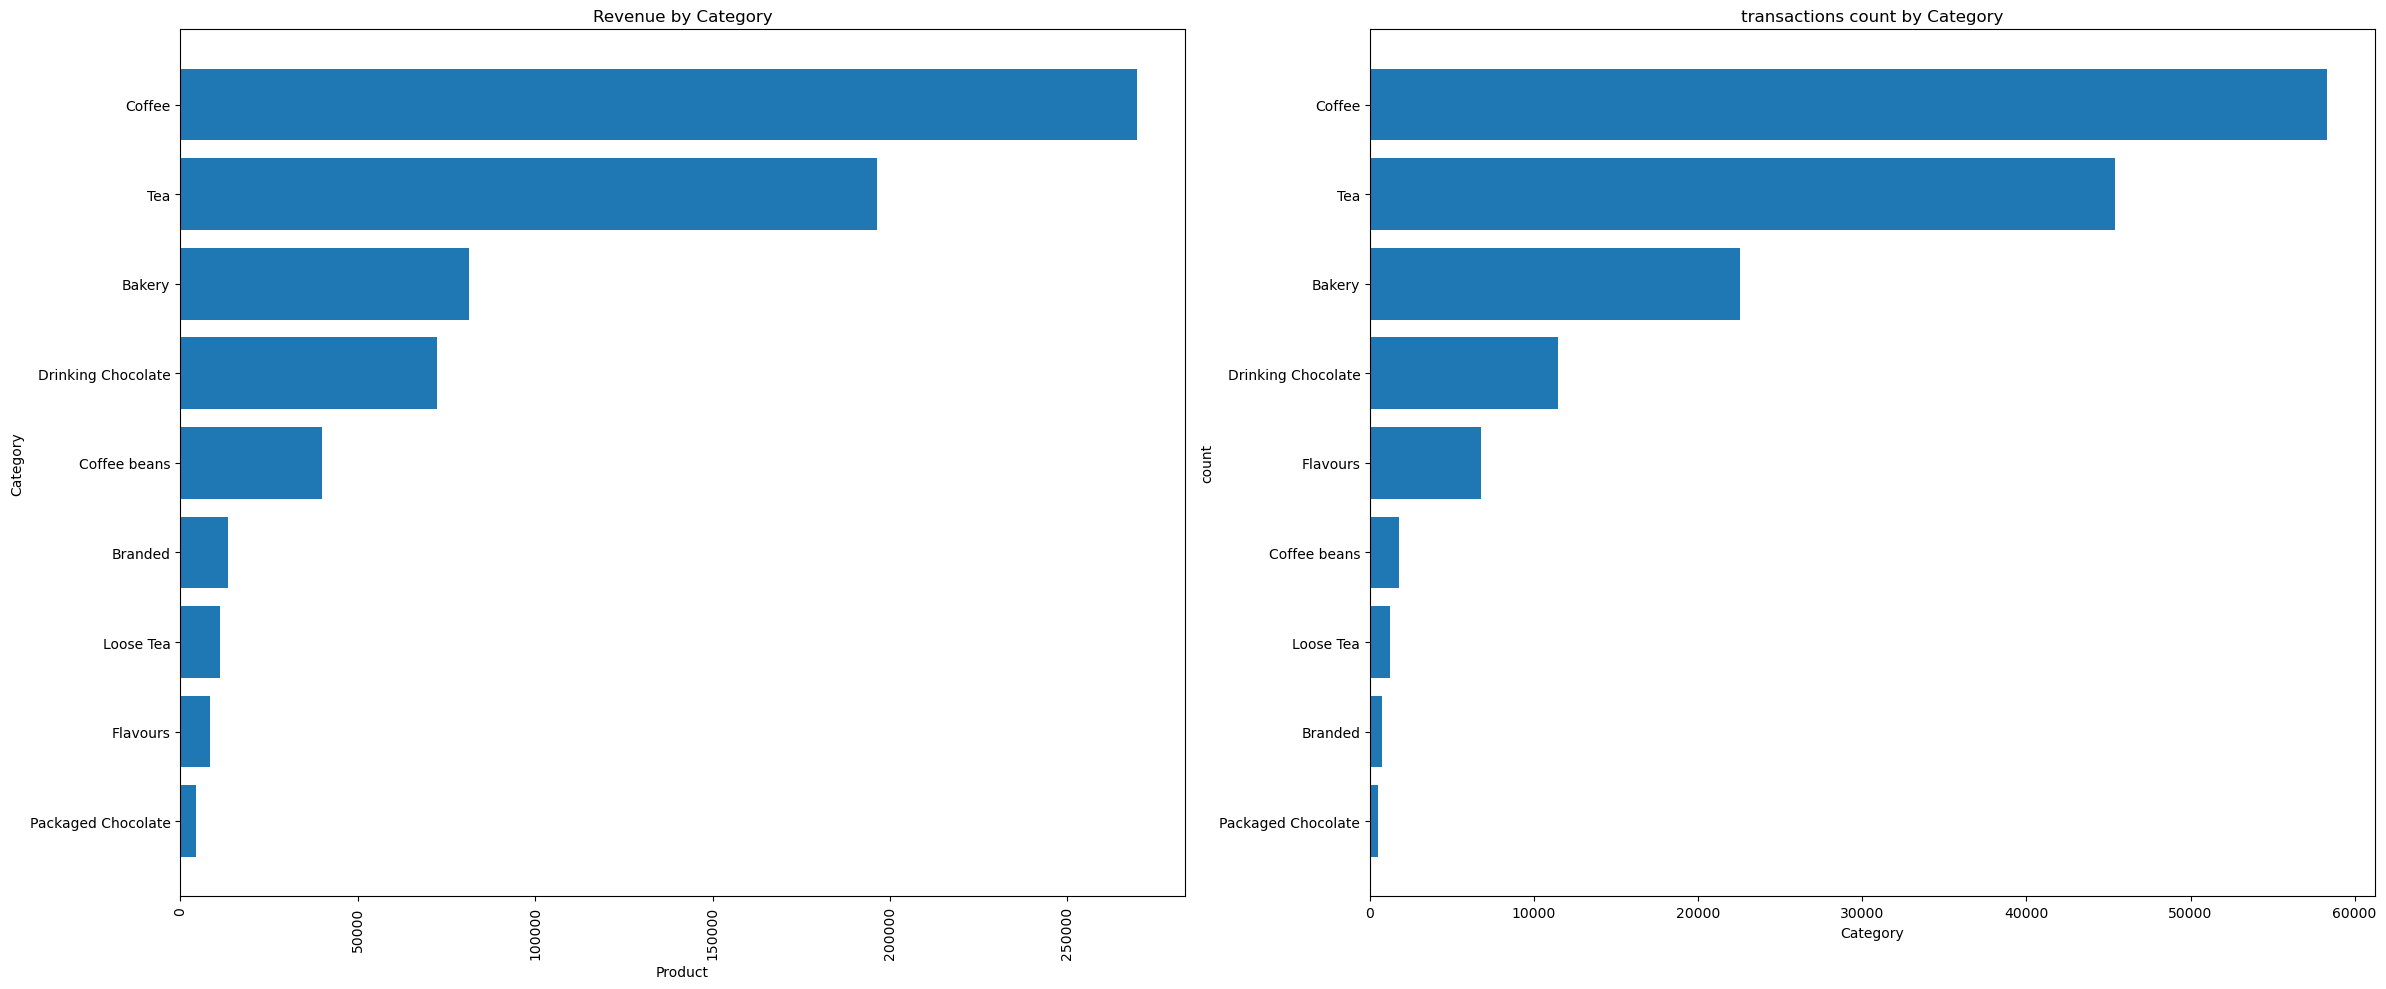

In [23]:
# h-bar chart
fig, axs = plt.subplots(1, 2, figsize=(24,10))


# first graph || sales
axs[0].barh(rev_by_cat.index, rev_by_cat)
axs[0].set_title('Revenue by Category')
axs[0].set_xlabel('Product')
axs[0].set_ylabel('Category')
axs[0].tick_params(axis='x', rotation=90)


# second graph || sales
axs[1].barh(tc_by_cat.index,tc_by_cat)
axs[1].set_title('transactions count by Category')
axs[1].set_xlabel('Category')
axs[1].set_ylabel('count')
plt.tight_layout()

plt.show()

## Revenue & Transactions count by day

In [25]:
# Revenue & Transaction by day
rev_d = df.groupby(by=['transaction_date'])['revenue'].sum()
tc_d = df.groupby(by=['transaction_date'])['transaction_qty'].count()

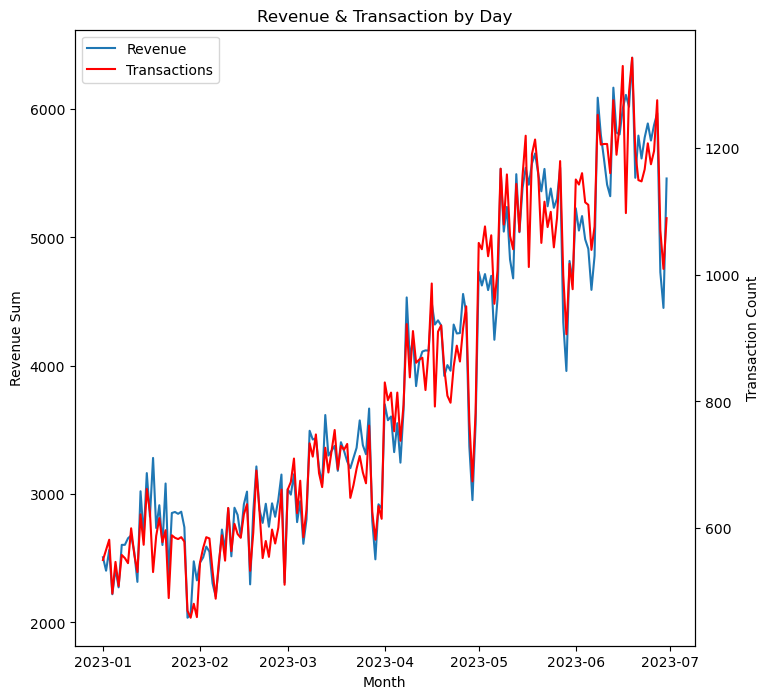

In [26]:
fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()
plt.title('Revenue & Transaction by Day')
# first plot
ax1.plot(rev_d, label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue Sum')

# second plot
ax2.plot(tc_d, color='red', label='Transactions')
ax2.set_ylabel('Transaction Count')

# Gather the handles and labels from both axes
lines_ax1, labels_ax1 = ax1.get_legend_handles_labels()  # Get lines and labels from ax1
lines_ax2, labels_ax2 = ax2.get_legend_handles_labels()  # Get lines and labels from ax2

# Combine the handles and labels from both axes
lines = lines_ax1 + lines_ax2
labels = labels_ax1 + labels_ax2

# Add the legend
ax1.legend(lines, labels, loc='upper left')
plt.show()

## Revenue & Transactions count by Store

In [28]:
# average revenue by store
rev_s = df.groupby(df['store_location'])['revenue'].mean().sort_values()
# tc by store
tc_s = df.groupby(df['store_location'])['transaction_qty'].count().sort_values()

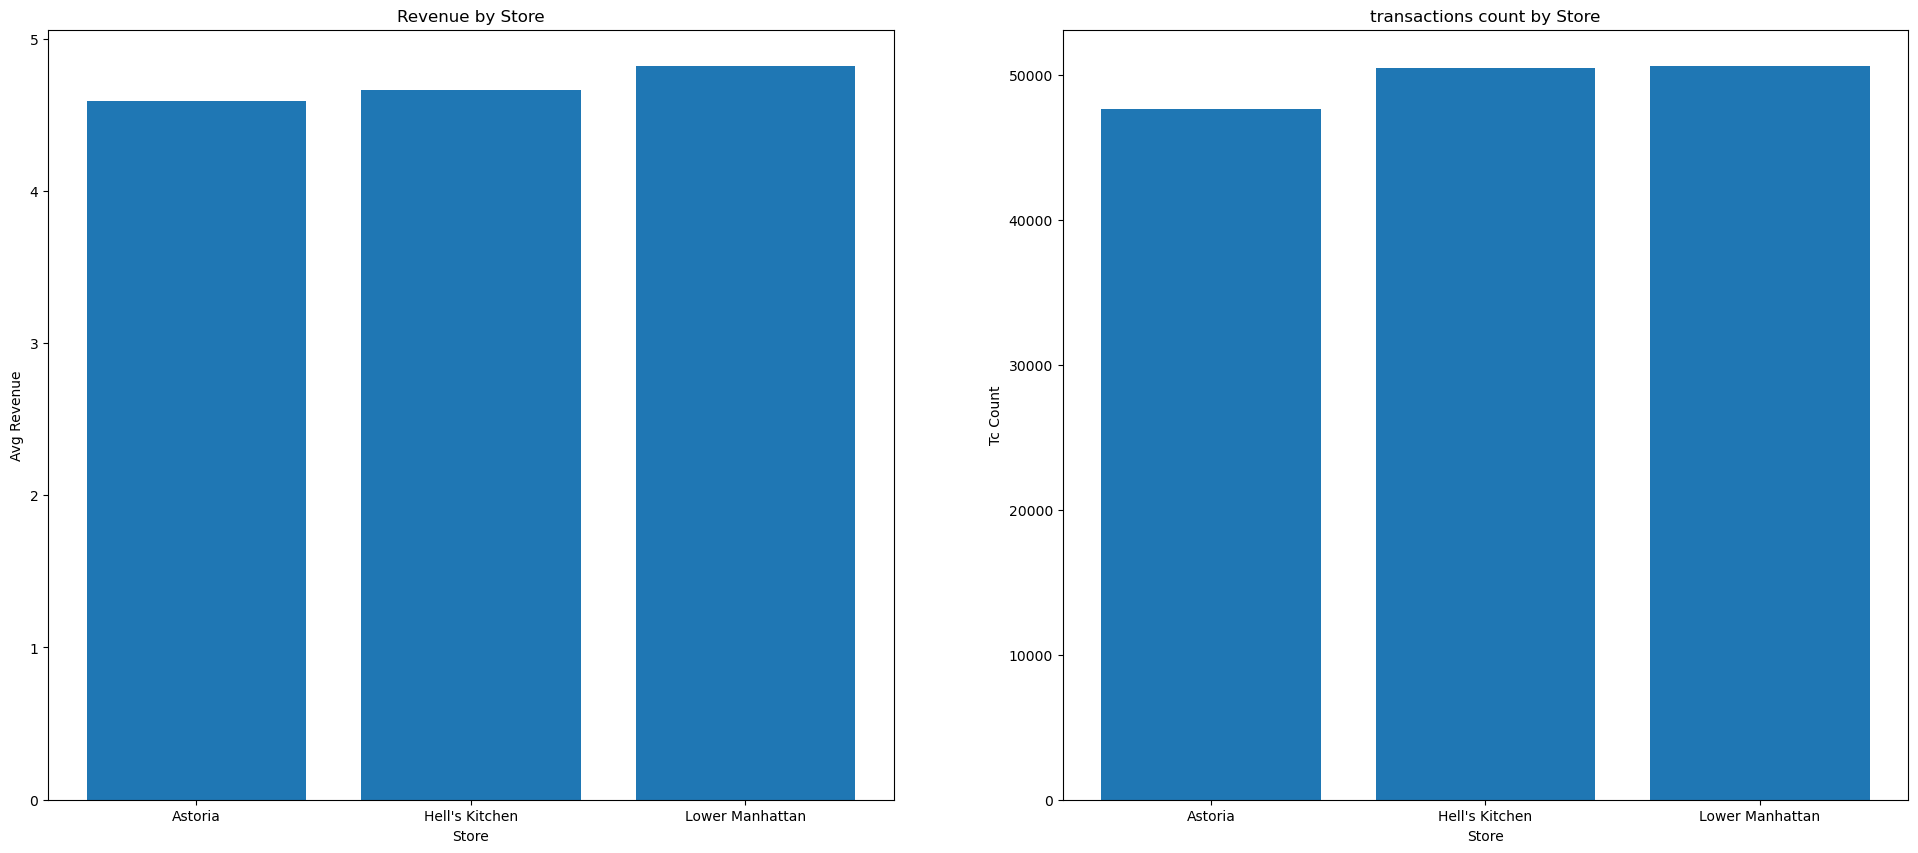

In [29]:
# h-bar chart
fig, axs = plt.subplots(1, 2, figsize=(24,10))

# first graph || sales
axs[0].bar(rev_s.index, rev_s)
axs[0].set_title('Revenue by Store')
axs[0].set_xlabel('Store')
axs[0].set_ylabel('Avg Revenue')

# second graph || sales
axs[1].bar(rev_s.index, tc_s)
axs[1].set_title('transactions count by Store')
axs[1].set_xlabel('Store')
axs[1].set_ylabel('Tc Count')

plt.savefig('rev_&_tc_by_store')
plt.show()

## Ml Part

In [31]:
df.select_dtypes(include='number').groupby('revenue').mean()

,transaction_qty,store_id,product_id,unit_price
revenue,,,,
0.8,1.0,5.586368,69.040772,0.8
1.6,2.0,5.650637,69.319235,0.8
2.0,1.0,5.242117,24.907575,2.0
2.1,1.0,7.250000,87.000000,2.1
2.2,1.0,5.213085,27.921053,2.2
...,...,...,...,...
36.0,2.0,5.000000,1.000000,18.0
45.0,1.0,5.900000,8.000000,45.0
56.0,4.0,5.000000,83.000000,14.0


In [32]:
from sklearn.model_selection import train_test_split
# inputs are based on Correlation
# target => revenue || inputs => [tc_count, unit_price, product_id]
target = df['revenue']
inputs = df[['transaction_qty', 'unit_price', 'product_id']]

x_train, x_test, y_train, y_test = train_test_split(target, inputs, test_size=0.2)

In [33]:
print(x_train.shape, y_train.shape)

(118974,) (118974, 3)


In [34]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(y_train, x_train)

LinearRegression()

In [35]:
model.score(y_test, x_test)

0.7690036607086634